## Simulaciones con potenciales suaves y cuadrados

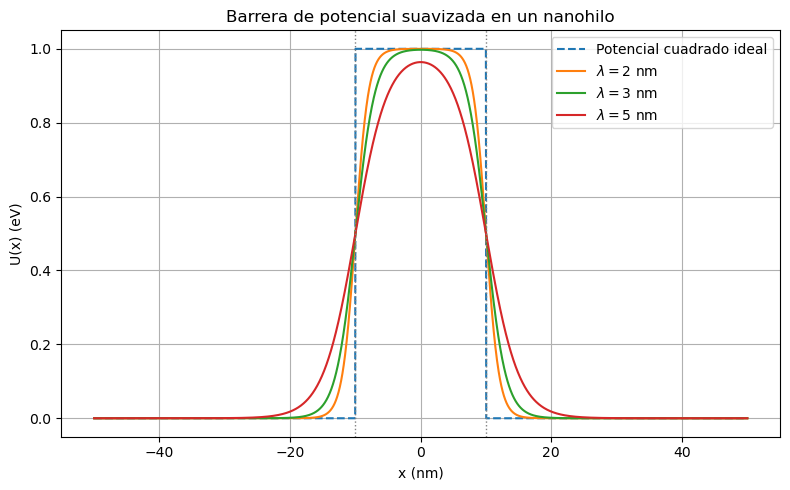

In [10]:
## CÓDIGO PARA PLOTEAR UN POTENCIAL CUADRADO SUAVE ####################

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS
# =========================================================
L = 100          # longitud total del nanohilo en nm
V0 = 1.0         # altura de la barrera en eV
B = 20           # anchura de la barrera en nm

lambda1 = 2      # suavidad del borde en nm
lambda2 = 3
lambda3 = 5

# =========================================================
# EJE X
# =========================================================
x = np.linspace(-L/2, L/2, 2000)

# =========================================================
# FUNCIÓN POTENCIAL
# =========================================================
def potencial_suave(x, V0, B, lamb):
    x0 = B/2
    U = (V0/2) * (np.tanh((x + x0)/lamb) - np.tanh((x - x0)/lamb))
    return U

# Potencial ideal cuadrado
def potencial_cuadrado(x, V0, B):
    U = np.zeros_like(x)
    for i in range(len(x)):
        if abs(x[i]) <= B/2:
            U[i] = V0
        else:
            U[i] = 0
    return U

U_ideal = potencial_cuadrado(x, V0, B)
U_lam1 = potencial_suave(x, V0, B, lambda1)
U_lam2 = potencial_suave(x, V0, B, lambda2)
U_lam3 = potencial_suave(x, V0, B, lambda3)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(x, U_ideal, "--", label="Potencial cuadrado ideal")
plt.plot(x, U_lam1, label=r"$\lambda = 2$ nm")
plt.plot(x, U_lam2, label=r"$\lambda = 3$ nm")
plt.plot(x, U_lam3, label=r"$\lambda = 5$ nm")

plt.axvline(-B/2, color="gray", linestyle=":", linewidth=1)
plt.axvline(B/2, color="gray", linestyle=":", linewidth=1)

plt.xlabel("x (nm)")
plt.ylabel("U(x) (eV)")
plt.title("Barrera de potencial suavizada en un nanohilo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Transmisión para una barrera cuadrada y una suave

hbar^2 / 2m* = 1.6565130434782611 eV nm^2


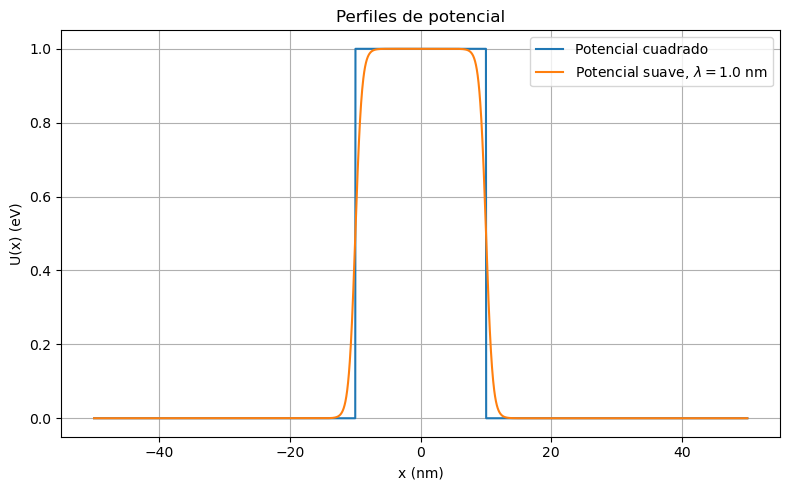

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS FÍSICOS
# =========================================================

L = 100.0          # longitud total del nanohilo en nm
V0 = 1.0           # altura de la barrera en eV
B = 20.0           # anchura de la barrera en nm
lamb = 1.0         # suavidad de los bordes en nm

m_rel = 0.023      # masa efectiva GaAs: m* = 0.067 m0

# Constante hbar^2 / 2m0 en eV nm^2
hbar2_2m0 = 0.0380998

# Para masa efectiva m* = m_rel m0:
hbar2_2m = hbar2_2m0 / m_rel

print("hbar^2 / 2m* =", hbar2_2m, "eV nm^2")

# =========================================================
# MALLA ESPACIAL
# =========================================================

N = 3000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# =========================================================
# POTENCIALES
# =========================================================

def potencial_cuadrado(x, V0, B):
    """
    Barrera perfectamente cuadrada.
    V(x) = V0 si |x| <= B/2
    V(x) = 0 fuera
    """
    U = np.zeros_like(x)

    for i in range(len(x)):
        if abs(x[i]) <= B/2:
            U[i] = V0
        else:
            U[i] = 0.0

    return U


def potencial_suave(x, V0, B, lamb):
    """
    Barrera suavizada con tangentes hiperbólicas.
    
    U(x) = V0/2 * [tanh((x+B/2)/lambda) - tanh((x-B/2)/lambda)]
    """
    U = (V0/2) * (
        np.tanh((x + B/2)/lamb) -
        np.tanh((x - B/2)/lamb)
    )

    return U


U_cuadrado = potencial_cuadrado(x, V0, B)
U_suave = potencial_suave(x, V0, B, lamb)

# =========================================================
# PLOT DE LOS POTENCIALES
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(x, U_cuadrado, label="Potencial cuadrado")
plt.plot(x, U_suave, label=fr"Potencial suave, $\lambda={lamb}$ nm")

plt.xlabel("x (nm)")
plt.ylabel("U(x) (eV)")
plt.title("Perfiles de potencial")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# =========================================================
# MATRIZ DE PROPAGACIÓN EN UN TROZO DE POTENCIAL CONSTANTE
# =========================================================

def matriz_propagacion(E, U, dx, hbar2_2m):
    """
    Matriz que propaga la función de onda en un tramo dx
    donde el potencial vale U.

    Resuelve localmente:
        psi'' + k^2 psi = 0

    con:
        k^2 = (E - U) / (hbar^2 / 2m*)
    """

    k2 = (E - U) / hbar2_2m
    k = np.sqrt(k2 + 0j)   # +0j permite k complejo si E < U

    # Evitamos problemas numéricos si k es muy pequeño
    if abs(k) < 1e-12:
        M = np.array([
            [1.0, dx],
            [0.0, 1.0]
        ], dtype=complex)
    else:
        M = np.array([
            [np.cos(k*dx), np.sin(k*dx)/k],
            [-k*np.sin(k*dx), np.cos(k*dx)]
        ], dtype=complex)

    return M


# =========================================================
# FUNCIÓN PARA CALCULAR LA TRANSMISIÓN
# =========================================================

def transmision(E, U_array, dx, hbar2_2m):
    """
    Calcula la transmisión para una energía E atravesando un potencial U_array.
    
    Se supone que fuera del nanohilo el potencial vale 0:
        U_izquierda = 0
        U_derecha = 0
    """

    # Número de onda en las regiones libres de entrada y salida
    k0 = np.sqrt(E / hbar2_2m + 0j)

    if abs(k0) < 1e-12:
        return 0.0

    # Matriz total
    M_total = np.eye(2, dtype=complex)

    for U in U_array:
        M = matriz_propagacion(E, U, dx, hbar2_2m)
        M_total = M @ M_total

    # En la izquierda:
    # psi_L = exp(ikx) + r exp(-ikx)
    # En la derecha:
    # psi_R = t exp(ikx)
    #
    # Usamos vectores [psi, psi']

    a = np.array([1.0, 1j*k0], dtype=complex)      # onda incidente
    b = np.array([1.0, -1j*k0], dtype=complex)     # onda reflejada
    c = np.array([1.0, 1j*k0], dtype=complex)      # onda transmitida

    # M_total @ (a + r b) = t c
    #
    # r * (M_total @ b) - t * c = - M_total @ a

    A = np.column_stack((M_total @ b, -c))
    rhs = -M_total @ a

    r, t = np.linalg.solve(A, rhs)

    T = abs(t)**2

    return T.real

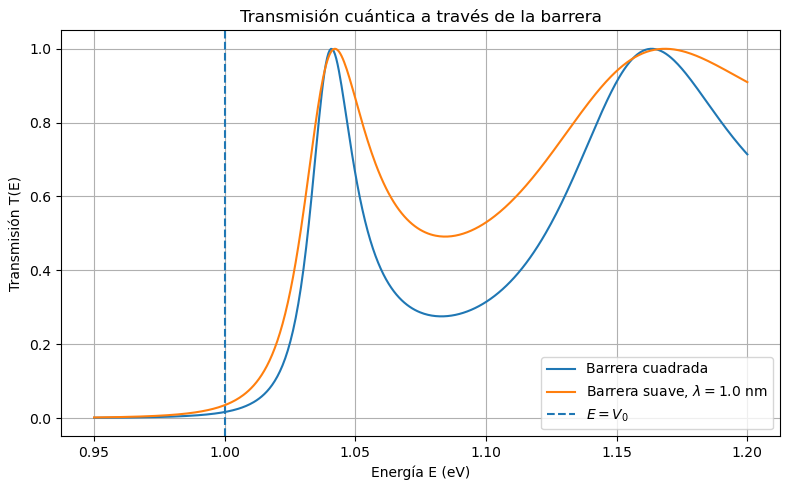

In [13]:
# =========================================================
# ARRAY DE ENERGÍAS
# =========================================================

Emin = 0.95      # eV
Emax = 1.2        # eV
NE = 500

E_array = np.linspace(Emin, Emax, NE)

T_cuadrado = np.zeros_like(E_array)
T_suave = np.zeros_like(E_array)

# =========================================================
# CÁLCULO DE TRANSMISIONES
# =========================================================

for i in range(len(E_array)):
    E = E_array[i]

    T_cuadrado[i] = transmision(E, U_cuadrado, dx, hbar2_2m)
    T_suave[i] = transmision(E, U_suave, dx, hbar2_2m)

# =========================================================
# PLOT DE LA TRANSMISIÓN
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(E_array, T_cuadrado, label="Barrera cuadrada")
plt.plot(E_array, T_suave, label=fr"Barrera suave, $\lambda={lamb}$ nm")

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Transmisión cuántica a través de la barrera")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

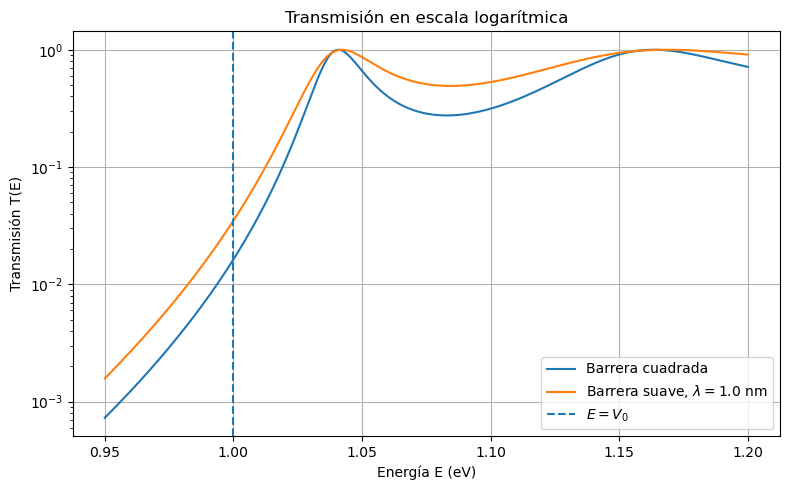

In [14]:
# =========================================================
# PLOT LOGARÍTMICO
# =========================================================

plt.figure(figsize=(8, 5))

plt.semilogy(E_array, T_cuadrado, label="Barrera cuadrada")
plt.semilogy(E_array, T_suave, label=fr"Barrera suave, $\lambda={lamb}$ nm")

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Transmisión en escala logarítmica")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

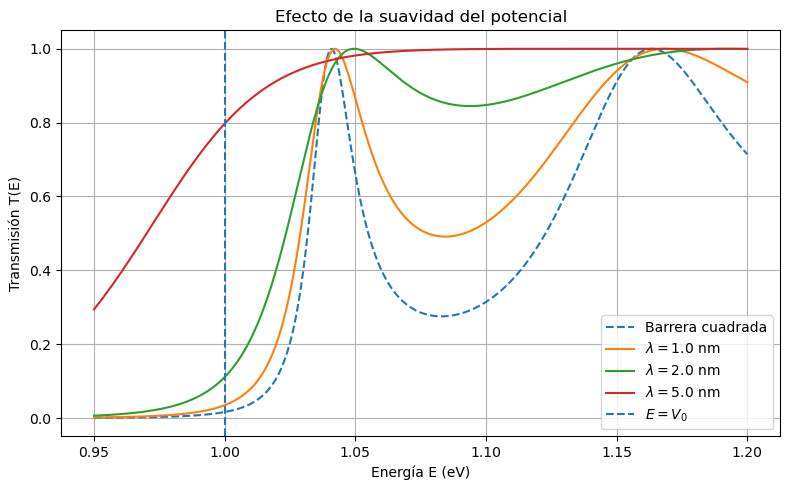

In [15]:
# =========================================================
# COMPARACIÓN PARA DISTINTOS LAMBDA
# =========================================================

lambdas = [1.0, 2.0, 5.0]

plt.figure(figsize=(8, 5))

plt.plot(E_array, T_cuadrado, "--", label="Barrera cuadrada")

for lamb_aux in lambdas:
    U_aux = potencial_suave(x, V0, B, lamb_aux)

    T_aux = np.zeros_like(E_array)

    for i in range(len(E_array)):
        T_aux[i] = transmision(E_array[i], U_aux, dx, hbar2_2m)

    plt.plot(E_array, T_aux, label=fr"$\lambda={lamb_aux}$ nm")

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Efecto de la suavidad del potencial")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Simulacion 1:
- Geometría (nm): 20-40-40-40-20
- Masas efectivas (eV): 0.067

## Transmisión para dos barreras separadas

Ahora ampliamos el código a una geometría de doble barrera:

\[
0 \; - \; V_0 \; - \; 0 \; - \; V_0 \; - \; 0
\]

donde:

- `A` es la anchura de cada barrera.
- `B` es la separación libre entre las dos barreras.
- `V0` es la altura común de las dos barreras.
- `lamb` controla cuánto se suavizan los bordes.

La barrera cuadrada tiene saltos bruscos. La barrera suave sustituye cada salto por una tangente hiperbólica.


hbar^2 / 2m* = 1.6565130434782611 eV nm^2


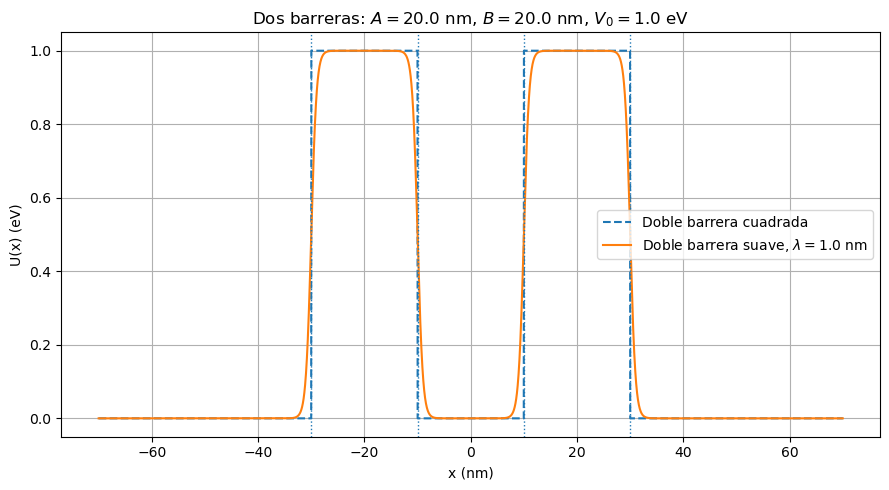

In [16]:
# =========================================================
# DOBLE BARRERA: PARÁMETROS
# =========================================================

L = 140.0          # longitud total simulada del nanohilo en nm
V0 = 1.0           # altura de cada barrera en eV
A = 20.0           # anchura de cada barrera en nm
B = 20.0           # separación entre barreras en nm
lamb = 1.0         # suavidad de los bordes en nm

m_rel = 0.023      # masa efectiva: m* = m_rel m0

hbar2_2m0 = 0.0380998          # eV nm^2
hbar2_2m = hbar2_2m0 / m_rel

print("hbar^2 / 2m* =", hbar2_2m, "eV nm^2")

# =========================================================
# MALLA ESPACIAL
# =========================================================

N = 5000
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# =========================================================
# POTENCIALES DE DOBLE BARRERA
# =========================================================

def potencial_doble_cuadrado(x, V0, A, B):
    """
    Dos barreras cuadradas idénticas.

    Primera barrera:
        -B/2 - A <= x <= -B/2

    Segunda barrera:
         B/2 <= x <= B/2 + A

    Por tanto:
        A = anchura de cada barrera
        B = separación entre las dos barreras
    """
    U = np.zeros_like(x)

    for i in range(len(x)):
        condicion_izquierda = (-B/2 - A <= x[i] <= -B/2)
        condicion_derecha = (B/2 <= x[i] <= B/2 + A)

        if condicion_izquierda or condicion_derecha:
            U[i] = V0
        else:
            U[i] = 0.0

    return U


def barrera_suave_entre(x, V0, x1, x2, lamb):
    """
    Barrera suave entre x1 y x2.

    Si lamb es pequeño, se parece mucho a una barrera cuadrada.
    """
    U = (V0/2) * (
        np.tanh((x - x1)/lamb) -
        np.tanh((x - x2)/lamb)
    )

    return U


def potencial_doble_suave(x, V0, A, B, lamb):
    """
    Dos barreras idénticas suavizadas.
    Se construyen sumando dos barreras suaves individuales.
    """
    # Barrera izquierda
    x1_izq = -B/2 - A
    x2_izq = -B/2

    # Barrera derecha
    x1_der = B/2
    x2_der = B/2 + A

    U_izq = barrera_suave_entre(x, V0, x1_izq, x2_izq, lamb)
    U_der = barrera_suave_entre(x, V0, x1_der, x2_der, lamb)

    U = U_izq + U_der

    return U


U_doble_cuadrado = potencial_doble_cuadrado(x, V0, A, B)
U_doble_suave = potencial_doble_suave(x, V0, A, B, lamb)

# =========================================================
# PLOT DE LOS POTENCIALES
# =========================================================

plt.figure(figsize=(9, 5))

plt.plot(x, U_doble_cuadrado, "--", label="Doble barrera cuadrada")
plt.plot(x, U_doble_suave, label=fr"Doble barrera suave, $\lambda={lamb}$ nm")

# Líneas verticales para marcar la geometría ideal
plt.axvline(-B/2 - A, linestyle=":", linewidth=1)
plt.axvline(-B/2, linestyle=":", linewidth=1)
plt.axvline(B/2, linestyle=":", linewidth=1)
plt.axvline(B/2 + A, linestyle=":", linewidth=1)

plt.xlabel("x (nm)")
plt.ylabel("U(x) (eV)")
plt.title(fr"Dos barreras: $A={A}$ nm, $B={B}$ nm, $V_0={V0}$ eV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


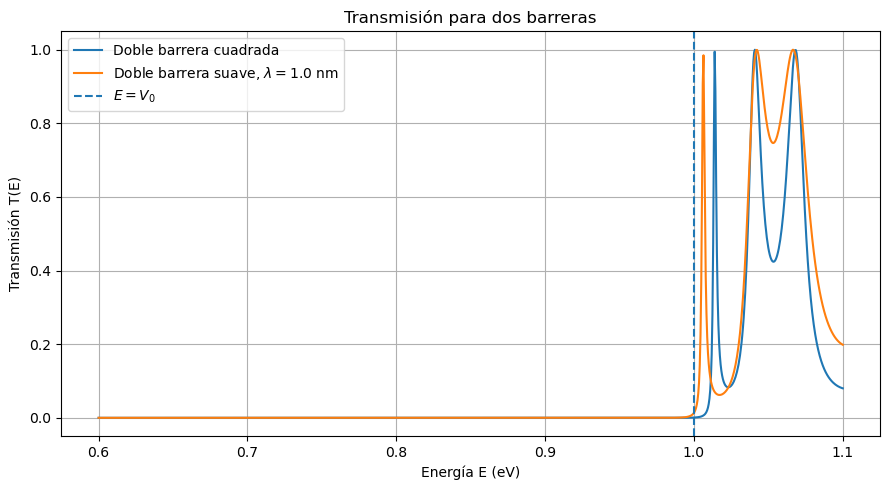

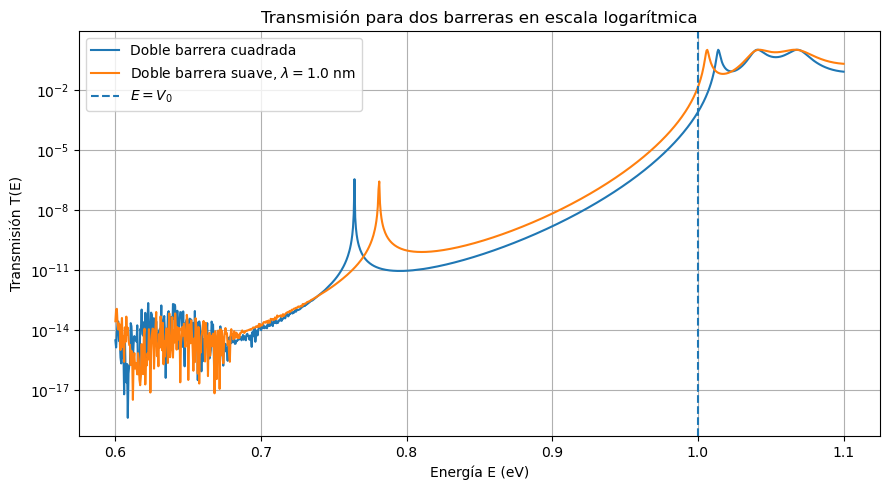

In [19]:
# =========================================================
# TRANSMISIÓN PARA DOS BARRERAS
# =========================================================

Emin = 0.6       # eV
Emax = 1.1       # eV
NE = 1000

E_array = np.linspace(Emin, Emax, NE)

T_doble_cuadrado = np.zeros_like(E_array)
T_doble_suave = np.zeros_like(E_array)

for i in range(len(E_array)):
    E = E_array[i]

    T_doble_cuadrado[i] = transmision(E, U_doble_cuadrado, dx, hbar2_2m)
    T_doble_suave[i] = transmision(E, U_doble_suave, dx, hbar2_2m)

# Evitamos pequeños errores numéricos por encima de 1
T_doble_cuadrado = np.clip(T_doble_cuadrado, 0, 1)
T_doble_suave = np.clip(T_doble_suave, 0, 1)

# =========================================================
# PLOT NORMAL
# =========================================================

plt.figure(figsize=(9, 5))

plt.plot(E_array, T_doble_cuadrado, label="Doble barrera cuadrada")
plt.plot(E_array, T_doble_suave, label=fr"Doble barrera suave, $\lambda={lamb}$ nm")

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Transmisión para dos barreras")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT LOGARÍTMICO
# =========================================================

plt.figure(figsize=(9, 5))

plt.semilogy(E_array, T_doble_cuadrado + 1e-30, label="Doble barrera cuadrada")
plt.semilogy(E_array, T_doble_suave + 1e-30, label=fr"Doble barrera suave, $\lambda={lamb}$ nm")

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Transmisión para dos barreras en escala logarítmica")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


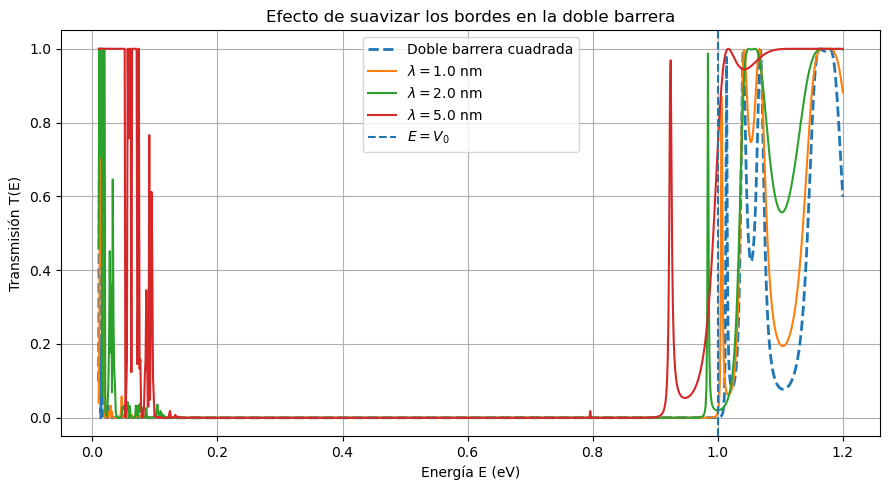

In [18]:
# =========================================================
# COMPARACIÓN DE LA SUAVIDAD PARA DOS BARRERAS
# =========================================================

lambdas = [1.0, 2.0, 5.0]

plt.figure(figsize=(9, 5))

plt.plot(E_array, T_doble_cuadrado, "--", linewidth=2, label="Doble barrera cuadrada")

for lamb_aux in lambdas:
    U_aux = potencial_doble_suave(x, V0, A, B, lamb_aux)
    T_aux = np.zeros_like(E_array)

    for i in range(len(E_array)):
        T_aux[i] = transmision(E_array[i], U_aux, dx, hbar2_2m)

    T_aux = np.clip(T_aux, 0, 1)

    plt.plot(E_array, T_aux, label=fr"$\lambda={lamb_aux}$ nm")

plt.axvline(V0, linestyle="--", label=r"$E=V_0$")

plt.xlabel("Energía E (eV)")
plt.ylabel("Transmisión T(E)")
plt.title("Efecto de suavizar los bordes en la doble barrera")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Nota importante

En esta parte he usado:

- `A` = anchura de cada barrera.
- `B` = separación entre barreras.

Lo hago así porque en una doble barrera hay dos longitudes distintas: la anchura de cada barrera y la anchura del pozo central que las separa. Si quieres recuperar la notación anterior, basta con renombrar `A` y `B`, pero físicamente conviene separarlas.
